In [14]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
BASE_DIR = "../data"

In [4]:
def load_train_data(file_name: str) -> pd.DataFrame:
    """
    Load training data from a CSV file.

    Args:
        file_name (str): The name of the CSV file to load.

    Returns:
        pd.DataFrame: The loaded data.
    """
    return pd.read_csv(f"{BASE_DIR}/{file_name}", parse_dates=["date"])

In [6]:
train_df = load_train_data("train.csv")
train_df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [7]:
train_df.isna().sum()

id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64

In [8]:
train_df.describe()

,id,date,store_nbr,sales,onpromotion
count,3.000888e+06,3000888,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2015-04-24 08:27:04.703088384,2.750000e+01,3.577757e+02,2.602770e+00
min,0.000000e+00,2013-01-01 00:00:00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,2014-02-26 18:00:00,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2015-04-24 12:00:00,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,2016-06-19 06:00:00,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,2017-08-15 00:00:00,5.400000e+01,1.247170e+05,7.410000e+02
std,8.662819e+05,NaN,1.558579e+01,1.101998e+03,1.221888e+01


In [12]:
print("Date range:", train_df["date"].min(), "to", train_df["date"].max())
print("Stores:", train_df["store_nbr"].nunique())
print("Family categories:", train_df["family"].nunique())
print("Family categories:", train_df["family"].unique())

Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00
Stores: 54
Family categories: 33
Family categories: ['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']


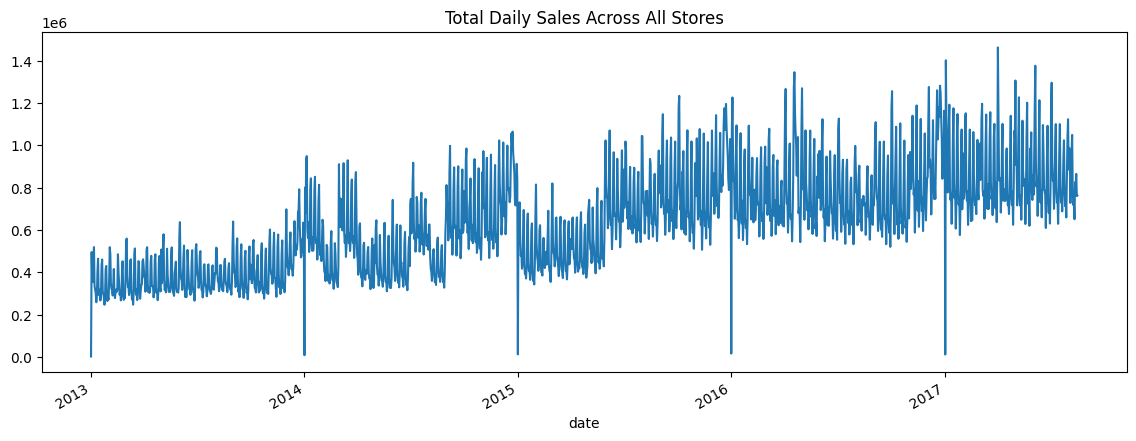

In [15]:
daily_sales = train_df.groupby("date")["sales"].sum()
daily_sales.plot(figsize=(14, 5), title="Total Daily Sales Across All Stores")
plt.show()

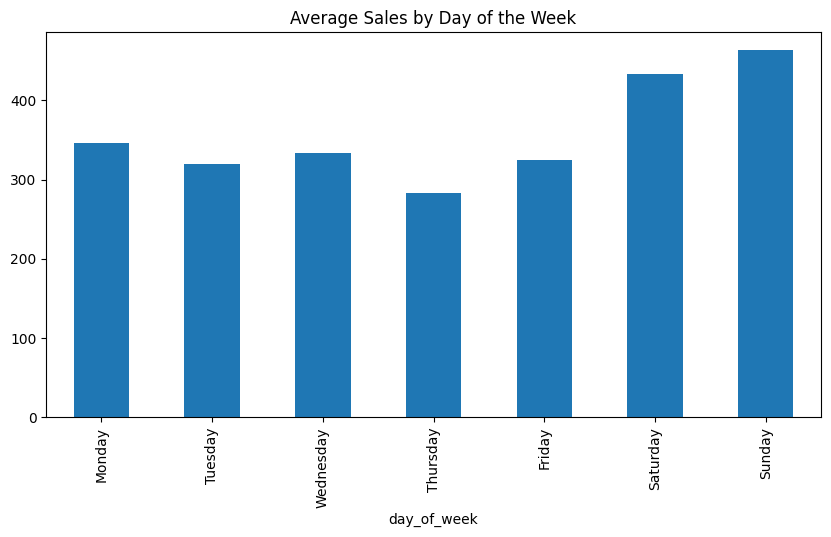

In [16]:
train_df["day_of_week"] = train_df["date"].dt.day_name()
train_df.groupby("day_of_week")["sales"].mean().reindex(
    ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
).plot(kind="bar", figsize=(10, 5), title="Average Sales by Day of the Week")
plt.show()

In [17]:
train_df["day_of_week_num"] = train_df["date"].dt.dayofweek
train_df["month"] = train_df["date"].dt.month
train_df["year"] = train_df["date"].dt.year
train_df["is_weekend"] = train_df["day_of_week_num"].isin([5, 6]).astype(int)

train_df[["date", "day_of_week_num", "month", "year", "is_weekend"]].head()

,date,day_of_week_num,month,year,is_weekend
0,2013-01-01,1,1,2013,0
1,2013-01-01,1,1,2013,0
2,2013-01-01,1,1,2013,0
3,2013-01-01,1,1,2013,0
4,2013-01-01,1,1,2013,0


In [19]:
oil_df = load_train_data("oil.csv")
holidays_df = load_train_data("holidays_events.csv")
stores_df = pd.read_csv(f"{BASE_DIR}/stores.csv")

In [20]:
national_holidays = holidays_df[
    (holidays_df["locale"] == "National") & (holidays_df["transferred"] == False)
]["date"].unique()

train_df["is_holiday"] = train_df["date"].isin(national_holidays).astype(int)
train_df["is_holiday"].value_counts()

is_holiday
0    2758536
1     242352
Name: count, dtype: int64

In [21]:
train_df = train_df.merge(oil_df, on="date", how="left")
train_df["dcoilwtico"] = train_df["dcoilwtico"].ffill().bfill()
train_df[["date", "dcoilwtico"]].head()

,date,dcoilwtico
0,2013-01-01,93.14
1,2013-01-01,93.14
2,2013-01-01,93.14
3,2013-01-01,93.14
4,2013-01-01,93.14


In [22]:
train_df = train_df.merge(stores_df, on="store_nbr", how="left")
train_df[["store_nbr", "city", "state", "type", "cluster"]].drop_duplicates().head()

,store_nbr,city,state,type,cluster
0,1,Quito,Pichincha,D,13
33,10,Quito,Pichincha,C,15
66,11,Cayambe,Pichincha,B,6
99,12,Latacunga,Cotopaxi,C,15
132,13,Latacunga,Cotopaxi,C,15


In [23]:
train_df = train_df.sort_values(["store_nbr", "family", "date"])
train_df["sales_lag_7"] = train_df.groupby(["store_nbr", "family"])["sales"].shift(7)
train_df[["store_nbr", "family", "date", "sales", "sales_lag_7"]].head(10)

,store_nbr,family,date,sales,sales_lag_7
0,1,AUTOMOTIVE,2013-01-01,0.0,NaN
1782,1,AUTOMOTIVE,2013-01-02,2.0,NaN
3564,1,AUTOMOTIVE,2013-01-03,3.0,NaN
5346,1,AUTOMOTIVE,2013-01-04,3.0,NaN
7128,1,AUTOMOTIVE,2013-01-05,5.0,NaN
8910,1,AUTOMOTIVE,2013-01-06,2.0,NaN
10692,1,AUTOMOTIVE,2013-01-07,0.0,NaN
12474,1,AUTOMOTIVE,2013-01-08,2.0,0.0
14256,1,AUTOMOTIVE,2013-01-09,2.0,2.0
16038,1,AUTOMOTIVE,2013-01-10,2.0,3.0
